# Notebook 2 — Feature Engineering
**Projet IndabaX 2026 — Cameroun** | Prédiction du VRI — horizon **7 jours**

Prérequis : exécuter `01_EDA.ipynb` → génère `../outputs/df_clean.pkl`

Pipeline : Chargement → Features temporelles → Lags/Rolling → VRI_v2 → Split → Normalisation → Sauvegarde


In [1]:
import pandas as pd
import numpy as np
import pickle, os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Constantes globales ──
HORIZON      = 7       # horizon de prédiction unique : t+7 jours
TEST_YEAR    = 2025
RANDOM_STATE = 42

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

print(f'Imports OK  |  Horizon de prédiction : t+{HORIZON} jours')


Imports OK  |  Horizon de prédiction : t+7 jours


## 1. Chargement du contexte EDA


In [2]:
df_clean     = pickle.load(open('../outputs/df_clean.pkl',    'rb'))
NUMERIC_COLS = pickle.load(open('../outputs/numeric_cols.pkl','rb'))

print(f'df_clean chargé : {df_clean.shape}')
print(f'Période : {df_clean["time"].min().date()} → {df_clean["time"].max().date()}')
print(f'Villes  : {df_clean["city"].nunique()} | Régions : {df_clean["region"].nunique()}')
print(f'Colonnes VRI présentes : {[c for c in df_clean.columns if "VRI" in c or "opt" in c.lower()]}')


df_clean chargé : (87240, 35)
Période : 2020-01-01 → 2025-12-20
Villes  : 40 | Régions : 10
Colonnes VRI présentes : ['T_opt', 'HR_opt', 'P_opt', 'VRI']


## 2. Feature Engineering
- **Features temporelles** : `day_of_year`, `month`, `week_of_year` + encodage cyclique sin/cos
- **Lags VRI** : t−1, t−2, t−3, t−7, t−10, t−14, t−21, t−30 (tous ≥ 1 → pas de fuite pour t+7)
- **Fenêtres glissantes** : mean/std/max sur 7, 14, 30 jours
- **Anomalie** : VRI − climatologie mensuelle par ville
- **Cible unique** : `target_t7` = VRI à t+7
- `year` exclu de FEATURE_COLS (data leakage temporel)


In [3]:
def add_features(df, horizon=HORIZON):
    out = df.copy().reset_index(drop=True)

    # ── Features temporelles ──
    out['day_of_year']  = out['time'].dt.dayofyear
    out['month']        = out['time'].dt.month
    out['year']         = out['time'].dt.year
    out['week_of_year'] = out['time'].dt.isocalendar().week.astype(int)

    # Encodage cyclique (continuité Jan–Déc et Jour 1–365)
    out['sin_doy']   = np.sin(2 * np.pi * out['day_of_year'] / 365.25)
    out['cos_doy']   = np.cos(2 * np.pi * out['day_of_year'] / 365.25)
    out['sin_month'] = np.sin(2 * np.pi * out['month'] / 12)
    out['cos_month'] = np.cos(2 * np.pi * out['month'] / 12)

    # ── Lags VRI par ville (tous ≥ 1 → aucune fuite pour horizon t+7) ──
    for lag in [1, 2, 3, 7, 10, 14, 21, 30]:
        out[f'VRI_lag_{lag}'] = out.groupby('city')['VRI'].transform(
            lambda x, l=lag: x.shift(l))

    # ── Fenêtres glissantes VRI ──
    for w in [7, 14, 30]:
        grp = out.groupby('city')['VRI']
        out[f'VRI_roll{w}_mean'] = grp.transform(lambda x, ww=w: x.rolling(ww, min_periods=1).mean())
        out[f'VRI_roll{w}_std']  = grp.transform(lambda x, ww=w: x.rolling(ww, min_periods=1).std().fillna(0))
        out[f'VRI_roll{w}_max']  = grp.transform(lambda x, ww=w: x.rolling(ww, min_periods=1).max())

    # ── Anomalie climatologique mensuelle par ville ──
    clim = (out.groupby(['city','month'])['VRI'].mean().reset_index()
               .rename(columns={'VRI':'VRI_clim_month'}))
    out = out.merge(clim, on=['city','month'], how='left').reset_index(drop=True)
    out['VRI_anomaly'] = out['VRI'] - out['VRI_clim_month']

    # ── Features météo dérivées ──
    out['precip_cum7']  = out.groupby('city')['precipitation_sum'].transform(
        lambda x: x.rolling(7,  min_periods=1).sum())
    out['precip_cum15'] = out.groupby('city')['precipitation_sum'].transform(
        lambda x: x.rolling(15, min_periods=1).sum())
    out['temp_roll7']   = out.groupby('city')['temp_mean'].transform(
        lambda x: x.rolling(7, min_periods=1).mean())

    # ── Encodage ville ──
    le = LabelEncoder()
    out['city_enc'] = le.fit_transform(out['city'])
    city_stats = (out.groupby('city')['VRI']
                     .agg(city_vri_mean='mean', city_vri_std='std').reset_index())
    out = out.merge(city_stats, on='city', how='left').reset_index(drop=True)

    # ── Cible unique : VRI à t+7 ──
    out[f'target_t{horizon}'] = out.groupby('city')['VRI'].transform(
        lambda x, hh=horizon: x.shift(-hh))

    return out

df_feat = add_features(df_clean)
new_cols = df_feat.shape[1] - df_clean.shape[1]
print(f'Features ajoutées : {new_cols} nouvelles colonnes')
print(f'Dimensions finales : {df_feat.shape}')
print(f'Cible créée : target_t{HORIZON} — NaN attendus (derniers {HORIZON} jours/ville) :')
print(f'  NaN = {df_feat[f"target_t{HORIZON}"].isnull().sum()} '
      f'({df_feat["city"].nunique()} villes × {HORIZON} jours)')


Features ajoutées : 34 nouvelles colonnes
Dimensions finales : (87240, 69)
Cible créée : target_t7 — NaN attendus (derniers 7 jours/ville) :
  NaN = 280 (40 villes × 7 jours)


## 3. VRI_v2 — Lissage EMA-14 (nouvelle formule pondérée)
On applique une **EMA-14** sur chaque composante de la **nouvelle formule pondérée** :

$$VRI\_v2 = \left(0.4 \cdot \widetilde{T}_{opt} + 0.35 \cdot \widetilde{HR}_{opt} + 0.25 \cdot \widetilde{P}_{opt}\right) \times (1 - \widetilde{S})$$

où $\widetilde{x} = EMA(x,\, span=14)$ — donne plus de poids aux 2 dernières semaines.

**Justification biologique** : les moustiques réagissent aux conditions accumulées sur ~2 semaines,
pas uniquement au jour J. Le lissage EMA réduit aussi le bruit des précipitations sporadiques.

> VRI_v2 reste strictement dans **[0, 1]** par construction (moyenne pondérée × facteur binaire lissé).


Distribution VRI_v2 (nouvelle formule pondérée + EMA-14) :
count    87240.0000
mean         0.3985
std          0.3396
min          0.0000
25%          0.0001
50%          0.5360
75%          0.7174
max          0.9630
Name: VRI_v2, dtype: float64
VRI_v2 dans [0,1] : True
Corrélation VRI / VRI_v2 : 0.9530


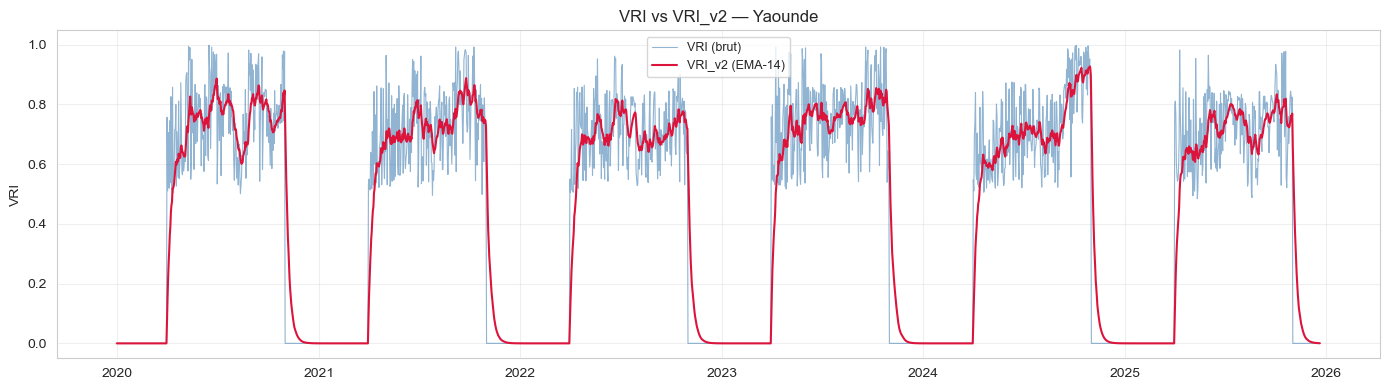

In [4]:
def add_vri_v2(df, span: int = 14) -> pd.DataFrame:
    """
    Calcule VRI_v2 avec la nouvelle formule pondérée lissée par EMA.
    VRI_v2 = (0.4*EMA(T_opt) + 0.35*EMA(HR_opt) + 0.25*EMA(P_opt)) * (1 - EMA(S))
    Résultat strictement dans [0, 1].
    """
    out = df.copy()

    # Lissage EMA par ville pour chaque composante
    for col in ['T_opt', 'HR_opt', 'P_opt', 'is_dry_season']:
        if col not in out.columns:
            print(f'  ⚠ Colonne {col} absente — ignorée')
            continue
        out[f'{col}_ema'] = (
            out.groupby('city')[col]
               .transform(lambda x: x.ewm(span=span, adjust=False).mean())
        )

    # Vérification des colonnes EMA disponibles
    required = ['T_opt_ema', 'HR_opt_ema', 'P_opt_ema', 'is_dry_season_ema']
    missing  = [c for c in required if c not in out.columns]
    if missing:
        print(f'Colonnes manquantes pour VRI_v2 : {missing}')
        return out

    # Nouvelle formule pondérée sur composantes lissées
    out['VRI_v2'] = (
        0.40 * out['T_opt_ema'] +
        0.35 * out['HR_opt_ema'] +
        0.25 * out['P_opt_ema']
    ) * (1 - out['is_dry_season_ema'])

    return out

df_feat = add_vri_v2(df_feat, span=14)

if 'VRI_v2' in df_feat.columns:
    print('Distribution VRI_v2 (nouvelle formule pondérée + EMA-14) :')
    print(df_feat['VRI_v2'].describe().round(4))
    print(f'VRI_v2 dans [0,1] : {df_feat["VRI_v2"].between(0,1).all()}')
    print(f'Corrélation VRI / VRI_v2 : {df_feat[["VRI","VRI_v2"]].corr().iloc[0,1]:.4f}')

    # Visualisation VRI vs VRI_v2 sur une ville
    ville_v = 'Yaounde' if 'Yaounde' in df_feat['city'].values else df_feat['city'].iloc[0]
    s = df_feat[df_feat['city'] == ville_v].sort_values('time')
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(s['time'], s['VRI'],    linewidth=0.8, alpha=0.6, color='steelblue', label='VRI (brut)')
    ax.plot(s['time'], s['VRI_v2'], linewidth=1.5, color='crimson', label='VRI_v2 (EMA-14)')
    ax.set_title(f'VRI vs VRI_v2 — {ville_v}', fontsize=12)
    ax.set_ylabel('VRI')
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()


## 4. Lags et rolling sur VRI_v2 + FEATURE_COLS réduite
On enrichit FEATURE_COLS avec les lags et rolling de VRI_v2.
La **cible finale** pour la modélisation VAR est `target_t7` basée sur VRI brut.

### Critères de sélection des features
| Catégorie | Variables | Raison |
|---|---|---|
| **Indispensables** | `T_opt`, `HR_opt`, `P_opt`, `is_dry_season` | Dans la formule VRI directement |
| **Indispensables** | `VRI_lag_7/14/21/30`, `VRI_roll*` | Cœur du modèle VAR (autorégressif) |
| **Nécessaires** | `precipitation_sum`, `precipitation_hours`, `temperature_2m_mean` | Variables météo de la formule VRI |
| **Nécessaires** | `et0_fao_evapotranspiration`, `rain_sum` | Forte causalité Granger attendue |
| **Support** | `sin/cos_doy`, `sin/cos_month` | Capture la saisonnalité cyclique |

### Variables exclues
- Températures ressenties (`apparent_temperature_*`) → redondantes avec `temperature_2m_mean`
- Vent, rayonnement, durée d'ensoleillement → faible lien direct avec VRI
- Lags t-1, t-2, t-3 VRI brut → trop proches de t (peu utiles pour prédire t+7)
- `snowfall_sum` → toujours 0 au Cameroun


In [5]:
# ── Lags et rolling sur VRI_v2 ──
if 'VRI_v2' in df_feat.columns:
    for lag in [1, 7, 14]:
        df_feat[f'VRI_v2_lag_{lag}'] = df_feat.groupby('city')['VRI_v2'].transform(
            lambda x, l=lag: x.shift(l))
    df_feat['VRI_v2_roll7_mean'] = df_feat.groupby('city')['VRI_v2'].transform(
        lambda x: x.rolling(7, min_periods=1).mean())

# ── FEATURE_COLS réduite — variables indispensables et nécessaires au VAR ──
# Critère de sélection :
#   INDISPENSABLES : variables directement dans la formule VRI (T_opt, HR_opt, P_opt, is_dry_season)
#                   + VRI brut et ses lags (cœur du VAR) + cibles intermédiaires (VRI_v2)
#   NÉCESSAIRES    : variables météo avec forte causalité Granger attendue
#                   (precipitation_sum, precipitation_hours, et0_fao_evapotranspiration, rain_sum)
#   SUPPORT        : encodage ville, temporel cyclique (saisonnalité)
# EXCLUSIONS : température ressentie (redondante), vent/rayonnement (faible lien VRI),
#              lags météo bruts multiples (redondant avec rolling), latitude/longitude seules

FEATURE_COLS = [
    # ── Identité géographique ──
    'city_enc', 'city_vri_mean', 'city_vri_std',

    # ── Composantes VRI (indispensables — dans la formule) ──
    'T_opt', 'HR_opt', 'P_opt', 'is_dry_season',

    # ── VRI brut : lags indispensables pour VAR ──
    'VRI_lag_7', 'VRI_lag_14', 'VRI_lag_21', 'VRI_lag_30',

    # ── Rolling VRI (tendance récente) ──
    'VRI_roll7_mean', 'VRI_roll14_mean', 'VRI_roll30_mean',

    # ── Climatologie mensuelle (saisonnalité structurelle) ──
    'VRI_clim_month', 'VRI_anomaly',

    # ── VRI_v2 lissé EMA-14 (signal basse fréquence) ──
    'VRI_v2', 'VRI_v2_lag_7', 'VRI_v2_lag_14', 'VRI_v2_roll7_mean',

    # ── Météo indispensable (dans la formule VRI) ──
    'temperature_2m_mean', 'precipitation_sum', 'precipitation_hours',

    # ── Météo nécessaire (forte causalité Granger attendue) ──
    'et0_fao_evapotranspiration', 'rain_sum',

    # ── Features dérivées météo (cumuls précipitations — signal hydrique) ──
    'precip_cum7', 'precip_cum15',

    # ── Temporel cyclique (saisonnalité sin/cos) ──
    'sin_doy', 'cos_doy', 'sin_month', 'cos_month', 'month',
]

# Filtre défensif : garder uniquement les colonnes effectivement présentes
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_feat.columns]

print(f"FEATURE_COLS réduite : {len(FEATURE_COLS)} features (vs ~40+ avant)")
print(f"Cible : target_t{HORIZON}")

# Affichage structuré par catégorie
categories = {
    "Identité géographique"       : ['city_enc', 'city_vri_mean', 'city_vri_std'],
    "Composantes VRI"             : ['T_opt', 'HR_opt', 'P_opt', 'is_dry_season'],
    "Lags + Rolling VRI brut"     : [c for c in FEATURE_COLS if 'VRI_lag' in c or 'VRI_roll' in c],
    "Climatologie"                : ['VRI_clim_month', 'VRI_anomaly'],
    "VRI_v2 lissé"                : [c for c in FEATURE_COLS if 'VRI_v2' in c],
    "Météo indispensable"         : ['temperature_2m_mean', 'precipitation_sum', 'precipitation_hours'],
    "Météo nécessaire + dérivée"  : ['et0_fao_evapotranspiration', 'rain_sum', 'precip_cum7', 'precip_cum15'],
    "Temporel cyclique"           : ['sin_doy', 'cos_doy', 'sin_month', 'cos_month', 'month'],
}
for cat, cols in categories.items():
    present = [c for c in cols if c in FEATURE_COLS]
    if present:
        print(f"  {cat:35s} : {present}")

missing = [c for c in FEATURE_COLS if c not in df_feat.columns]
if missing:
    print(f"\n⚠ Features absentes du df_feat : {missing}")
else:
    print("\n✅ Toutes les features sont présentes dans df_feat")


FEATURE_COLS réduite : 32 features (vs ~40+ avant)
Cible : target_t7
  Identité géographique               : ['city_enc', 'city_vri_mean', 'city_vri_std']
  Composantes VRI                     : ['T_opt', 'HR_opt', 'P_opt', 'is_dry_season']
  Lags + Rolling VRI brut             : ['VRI_lag_7', 'VRI_lag_14', 'VRI_lag_21', 'VRI_lag_30', 'VRI_roll7_mean', 'VRI_roll14_mean', 'VRI_roll30_mean']
  Climatologie                        : ['VRI_clim_month', 'VRI_anomaly']
  VRI_v2 lissé                        : ['VRI_v2', 'VRI_v2_lag_7', 'VRI_v2_lag_14', 'VRI_v2_roll7_mean']
  Météo indispensable                 : ['temperature_2m_mean', 'precipitation_sum', 'precipitation_hours']
  Météo nécessaire + dérivée          : ['et0_fao_evapotranspiration', 'rain_sum', 'precip_cum7', 'precip_cum15']
  Temporel cyclique                   : ['sin_doy', 'cos_doy', 'sin_month', 'cos_month', 'month']

✅ Toutes les features sont présentes dans df_feat


## 5. Split temporel (Train / Validation / Test)
Split chronologique strict — toute inversion constitue un data leakage.
- **Train** : 2020–2023
- **Validation** : 2024
- **Test** : 2025

`year` conservé dans les DataFrames de split pour le filtrage mais **exclu** de FEATURE_COLS.


In [6]:
def make_split(df, horizon=HORIZON):
    """Split chronologique strict train/val/test pour un horizon donné."""
    target = f'target_t{horizon}'
    req    = FEATURE_COLS + [target, 'city', 'time', 'region', 'year']
    req    = [c for c in req if c in df.columns]
    dm     = df[req].dropna().reset_index(drop=True)

    train = dm[dm['year'] <= 2023].reset_index(drop=True)
    val   = dm[dm['year'] == 2024].reset_index(drop=True)
    test  = dm[dm['year'] == TEST_YEAR].reset_index(drop=True)

    return (train[FEATURE_COLS], train[target],
            val[FEATURE_COLS],   val[target],
            test[FEATURE_COLS],  test[target],
            train, val, test)

X_tr, y_tr, X_val, y_val, X_te, y_te, tr, v, te = make_split(df_feat, HORIZON)

print(f'Split horizon t+{HORIZON} :')
print(f'  Train      : {len(X_tr):>6,} obs | {tr["time"].min().date()} → {tr["time"].max().date()}')
print(f'  Validation : {len(X_val):>6,} obs | {v["time"].min().date()}  → {v["time"].max().date()}')
print(f'  Test       : {len(X_te):>6,} obs | {te["time"].min().date()}  → {te["time"].max().date()}')
print(f'  Features   : {len(FEATURE_COLS)}')

# Vérification anti-leakage
assert tr['time'].max() < v['time'].min(),  'LEAKAGE train/val !'
assert v['time'].max()  < te['time'].min(), 'LEAKAGE val/test !'
print('\nVérification anti-leakage : OK ✓')


Split horizon t+7 :
  Train      : 57,240 obs | 2020-01-31 → 2023-12-31
  Validation : 14,640 obs | 2024-01-01  → 2024-12-31
  Test       : 13,880 obs | 2025-01-01  → 2025-12-13
  Features   : 32

Vérification anti-leakage : OK ✓


## 6. Normalisation
| Méthode | Formule | Quand l'utiliser |
|---|---|---|
| **MinMaxScaler** | (x−min)/(max−min) → [0,1] | Distribution non gaussienne, MLP |
| **StandardScaler** | (x−μ)/σ → centré-réduit | Distribution ≈ gaussienne, modèles linéaires |
| **RobustScaler** | (x−médiane)/IQR | Présence d'outliers |
| **Aucune** | — | Arbres de décision (RF, XGBoost, LightGBM) |

> **Choix** : `StandardScaler` ajusté **uniquement sur le train** → évite le data leakage.
> Réservé au modèle linéaire baseline (VAR, Ridge). Les modèles à base d'arbres utilisent les données brutes.


In [7]:
# Features continues à scaler (on exclut les encodages et cycliques déjà dans [-1,1])
features_to_scale = [
    c for c in FEATURE_COLS
    if c not in ['city_enc', 'sin_doy', 'cos_doy', 'sin_month', 'cos_month',
                 'month', 'is_dry_season']
]

# Scaler ajusté UNIQUEMENT sur le train
scaler = StandardScaler()
scaler.fit(X_tr[features_to_scale])

def scale_split(X, scaler, cols):
    """Applique le scaler sur les colonnes continues sans toucher aux autres."""
    Xs = X.copy()
    Xs[cols] = scaler.transform(X[cols])
    return Xs

X_tr_sc  = scale_split(X_tr,  scaler, features_to_scale)
X_val_sc = scale_split(X_val, scaler, features_to_scale)
X_te_sc  = scale_split(X_te,  scaler, features_to_scale)

print(f'Features scalées     : {len(features_to_scale)}')
print(f'Features non scalées : {len(FEATURE_COLS) - len(features_to_scale)}')
print('Scaler fitted on train only ✓')

# Sauvegarde du scaler
os.makedirs('../outputs', exist_ok=True)
pickle.dump(scaler, open('../outputs/scaler.pkl', 'wb'), protocol=4)
print('Scaler sauvegardé : ../outputs/scaler.pkl')


Features scalées     : 25
Features non scalées : 7
Scaler fitted on train only ✓
Scaler sauvegardé : ../outputs/scaler.pkl


## 7. Sauvegarde — `df_feat.pkl`


In [8]:
os.makedirs('../outputs', exist_ok=True)

pickle.dump(df_feat,      open('../outputs/df_feat.pkl',            'wb'), protocol=4)
pickle.dump(FEATURE_COLS, open('../outputs/feature_cols_list.pkl',  'wb'), protocol=4)
pickle.dump((X_tr, y_tr, X_val, y_val, X_te, y_te, tr, v, te),
                          open('../outputs/split_t7.pkl',           'wb'), protocol=4)
pickle.dump((X_tr_sc, X_val_sc, X_te_sc),
                          open('../outputs/split_t7_scaled.pkl',    'wb'), protocol=4)

print('Fichiers sauvegardés :')
print('  ../outputs/df_feat.pkl            — DataFrame complet avec toutes les features')
print('  ../outputs/feature_cols_list.pkl  — Liste des features')
print(f'  ../outputs/split_t7.pkl           — Split train/val/test horizon t+{HORIZON}')
print('  ../outputs/split_t7_scaled.pkl    — Split standardisé (modèles linéaires)')
print('  ../outputs/scaler.pkl             — StandardScaler (fit sur train uniquement)')
print()
print(f'Shape df_feat   : {df_feat.shape}')
print(f'Features totales : {len(FEATURE_COLS)}')
print(f'Train / Val / Test : {len(X_tr):,} / {len(X_val):,} / {len(X_te):,} obs')


Fichiers sauvegardés :
  ../outputs/df_feat.pkl            — DataFrame complet avec toutes les features
  ../outputs/feature_cols_list.pkl  — Liste des features
  ../outputs/split_t7.pkl           — Split train/val/test horizon t+7
  ../outputs/split_t7_scaled.pkl    — Split standardisé (modèles linéaires)
  ../outputs/scaler.pkl             — StandardScaler (fit sur train uniquement)

Shape df_feat   : (87240, 78)
Features totales : 32
Train / Val / Test : 57,240 / 14,640 / 13,880 obs
